<a href="https://colab.research.google.com/github/PedroIvoLeite/Colab/blob/main/PMPMestrado_5000_Unique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Pré-Processamento de Dados usando Pandas (Python)**
Versão 1.0 10/04/2026
<h2>Mestrando: Pedro Ivo Santos Leite</h2>
<h3>Mestrado Profissional em Tecnologia da Informação</h3>
<b>Orientadores(as):</b>
<br>
Danyllo Albuquerque<br>




In [46]:
# consultando a versão do Python instalado na VM do Colab
!python -V

Python 3.12.13


# Carregamento de Bibliotecas

In [47]:
import pandas as pd
import numpy as np

# 1. Carga de Dados (5.000 questões únicas)

In [48]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive', force_remount=True)

# Caminho completo para o arquivo
file_path = '/content/drive/MyDrive/2026/PMP/pmp_dataset_5000_PRO_unique.csv'
# Carregando o dataset
df_questoes = pd.read_csv(file_path)

# Exibindo as primeiras linhas
df_questoes.head(3)

Mounted at /content/drive


,id,question,option_a,option_b,option_c,option_d,correct_answer,explanation,domain,eco_task,approach,difficulty,keywords,split,source,template_family
0,PMP-PRO-00001,"On a public sector modernization project, a pr...",Delay all project work until every stakeholder...,Tell the customer the change cannot be conside...,Review the benefits realization plan and adjus...,Replace the team member most closely associate...,C,Projects should remain aligned to business out...,Business,Support organizational change,Agile,medium,"compliance, value, benefits",train,synthetic_eco_aligned_pro,scenario
1,PMP-PRO-00002,A project manager is leading a new service lau...,Ignore the concern until it appears in the nex...,Update the schedule without consulting the aff...,Review expectations with the stakeholder and t...,Direct the team to work overtime until the iss...,C,Stakeholder engagement and clear expectations ...,People,Manage stakeholder expectations,Hybrid,easy,"leadership, conflict, stakeholders",train,synthetic_eco_aligned_pro,scenario
2,PMP-PRO-00003,A Agile project is underway for a supply chain...,Cancel the current iteration and restart the p...,Continue with the original plan because it was...,Assess compliance and business implications be...,Delay all project work until every stakeholder...,C,Business environment issues require evaluation...,Business,Manage business impact,Agile,medium,"value, strategy, governance",validation,synthetic_eco_aligned_pro,scenario


# 2. Explorando o Dataset

# 2.1 Metadados e Estatísticas

In [49]:
df_questoes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               5000 non-null   object
 1   question         5000 non-null   object
 2   option_a         5000 non-null   object
 3   option_b         5000 non-null   object
 4   option_c         5000 non-null   object
 5   option_d         5000 non-null   object
 6   correct_answer   5000 non-null   object
 7   explanation      5000 non-null   object
 8   domain           5000 non-null   object
 9   eco_task         5000 non-null   object
 10  approach         5000 non-null   object
 11  difficulty       5000 non-null   object
 12  keywords         5000 non-null   object
 13  split            5000 non-null   object
 14  source           5000 non-null   object
 15  template_family  5000 non-null   object
dtypes: object(16)
memory usage: 625.1+ KB


**Resumo visual dos tipos de dados**

| Tipo no Pandas |Exemplo   |Descrição   |
|----------------|----------|------------|
|int64 |42|Inteiros|
|float64|42.5|Decimais|
|bool|True|Lógico|
|object|"texto"|Strings ou mistura de tipos|
|datetime64|2023-12-25|Datas e Horários|
|category|"Nível 1"|Dados repetitivos (rótulos)|


**category:** Por que usar? Em vez de salvar a palavra "Brasil" mil vezes, o Pandas salva o número 0 e mantém um dicionário de mapeamento. **Isso reduz drasticamente o uso de memória em colunas com muitas repetições**.

**Dica de Performance**: Se você sabe que seus números são pequenos, pode converter para int32 ou float32 para **economizar metade da memória**.

In [50]:
df_questoes.describe()

,id,question,option_a,option_b,option_c,option_d,correct_answer,explanation,domain,eco_task,approach,difficulty,keywords,split,source,template_family
count,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000,5000
unique,5000,5000,30,30,30,30,4,15,3,30,3,3,180,3,1,1
top,PMP-PRO-05000,A Predictive project is underway for a regulat...,Delay all project work until every stakeholder...,Tell the customer the change cannot be conside...,Remove the item from scope to protect the base...,Escalate the issue immediately to the sponsor ...,C,Stakeholder engagement and clear expectations ...,People,Control scope,Hybrid,medium,"leadership, stakeholders, team",train,synthetic_eco_aligned_pro,scenario
freq,1,1,279,285,285,269,1270,359,1693,204,1706,2496,40,3497,5000,5000


In [51]:
# Número de linhas e atributos
df_questoes.shape

(5000, 16)

In [52]:
df_questoes.nunique()

,0
id,5000
question,5000
option_a,30
option_b,30
option_c,30
option_d,30
correct_answer,4
explanation,15
domain,3
eco_task,30


In [53]:
#Contagem de valores para uma coluna específica:
df_questoes['domain'].value_counts()

,count
domain,
People,1693
Business,1658
Process,1649


In [54]:
duplicated_count = df_questoes.duplicated().sum()
print("Quantidade de dados duplicados:", duplicated_count)

Quantidade de dados duplicados: 0


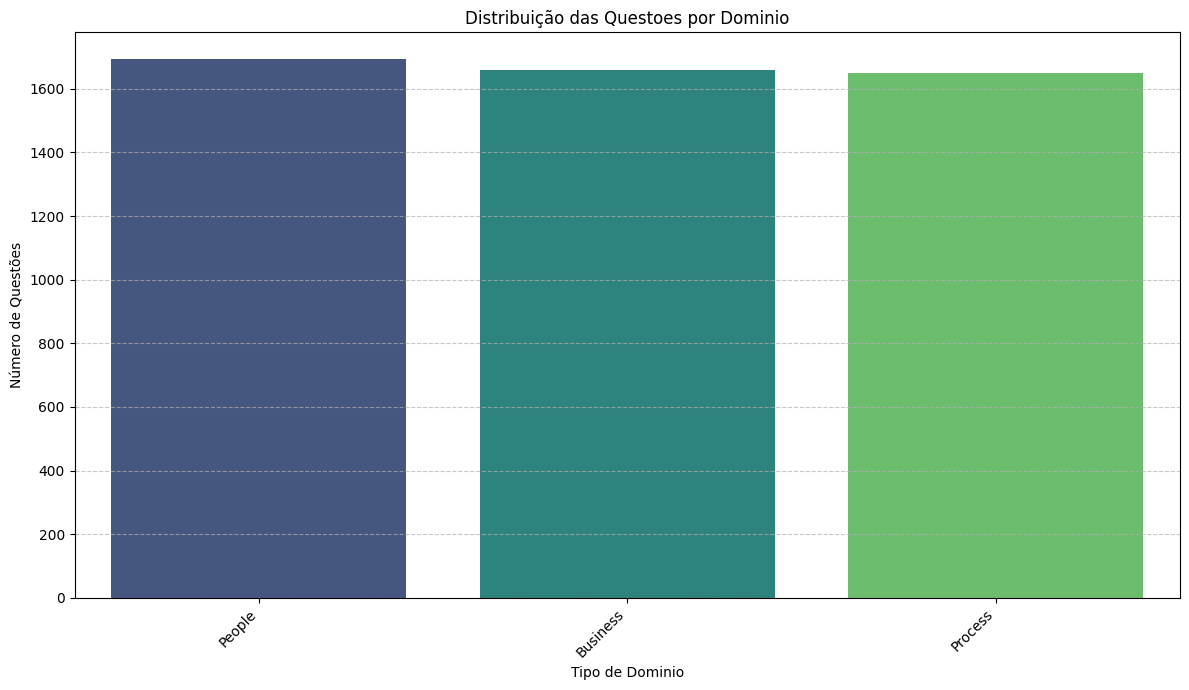

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contar a ocorrência de cada tipo de questao
distribuicao_tipo_res = df_questoes['domain'].value_counts()

# Criar o gráfico de barras
plt.figure(figsize=(12, 7))
sns.barplot(x=distribuicao_tipo_res.index, y=distribuicao_tipo_res.values, hue=distribuicao_tipo_res.index, palette='viridis', legend=False)
plt.title('Distribuição das Questoes por Dominio')
plt.xlabel('Tipo de Dominio')
plt.ylabel('Número de Questões')
plt.xticks(rotation=45, ha='right') # Rotacionar os rótulos do eixo x para melhor legibilidade
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar o layout para evitar sobreposição
plt.show()

### 1.1 Balanceamento dos Dominios
👉 Ideal: People ~33%, Process ~33%, Business ~33%

In [56]:
print(df_questoes['domain'].value_counts(normalize=True))

domain
People      0.3386
Business    0.3316
Process     0.3298
Name: proportion, dtype: float64


### 1.2 Balanceamento das Abordagem
👉 Ideal:Agile / Hybrid / Predictive equilibrados

In [57]:
print(df_questoes['approach'].value_counts(normalize=True))

approach
Hybrid        0.3412
Predictive    0.3306
Agile         0.3282
Name: proportion, dtype: float64


### 1.3 Dificuldade das Questões
👉 Ideal: easy / medium / hard equilibrados

In [58]:
print(df_questoes['difficulty'].value_counts(normalize=True))

difficulty
medium    0.4992
easy      0.2508
hard      0.2500
Name: proportion, dtype: float64


### 1.4 Distribuição das Respostas
👉 Ideal: A, B, C, D ~25% cada

👉 Problema comum: Muitas respostas “B” → modelo vicia

In [59]:
print(df_questoes['correct_answer'].value_counts(normalize=True))

correct_answer
C    0.2540
B    0.2522
D    0.2490
A    0.2448
Name: proportion, dtype: float64


In [60]:
df_questoes['question_length'] = df_questoes['question'].apply(len)
print(df_questoes['question_length'].describe())

count    5000.000000
mean      274.729600
std        41.289769
min       152.000000
25%       246.000000
50%       286.000000
75%       305.000000
max       366.000000
Name: question_length, dtype: float64


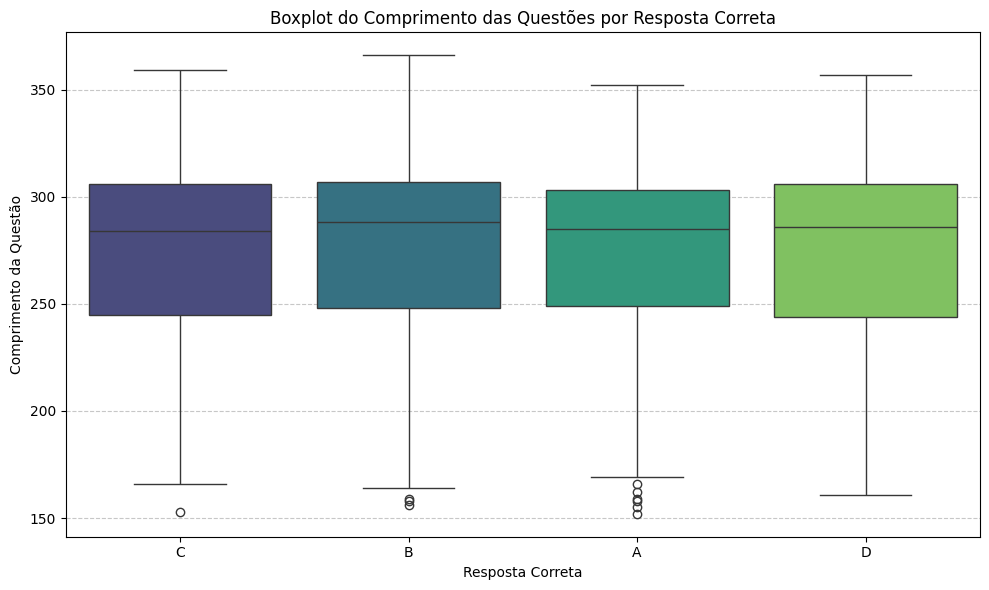

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

df_questoes['question_length'] = df_questoes['question'].apply(len)

plt.figure(figsize=(10, 6))
sns.boxplot(x='correct_answer', y='question_length', data=df_questoes, palette='viridis', hue='correct_answer', legend=False)
plt.title('Boxplot do Comprimento das Questões por Resposta Correta')
plt.xlabel('Resposta Correta')
plt.ylabel('Comprimento da Questão')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.5 Qualidade Textual das Questões (detectar dataset artificial)
👉 Muito homogêneo = suspeito (gerado)

In [62]:
# The 'question_length' column is now calculated within the boxplot cell for robustness.
# This cell's content is no longer needed in its original form.
# print(df_questoes['question_length'].describe())

In [82]:
# Calcular o IQR para 'question_length'
Q1 = df_questoes['question_length'].quantile(0.25)
Q3 = df_questoes['question_length'].quantile(0.75)
IQR = Q3 - Q1

# Definir os limites para outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identificar outliers
outliers = df_questoes[(df_questoes['question_length'] < lower_bound) | (df_questoes['question_length'] > upper_bound)]

print(f"Q1 (25º percentil): {Q1}")
print(f"Q3 (75º percentil): {Q3}")
print(f"IQR: {IQR}")
print(f"Limite Inferior para Outliers: {lower_bound}")
print(f"Limite Superior para Outliers: {upper_bound}")

print(f"\nNúmero de Outliers na 'question_length': {len(outliers)}")

if not outliers.empty:
    print("\nPrimeiras 5 linhas dos Outliers:\n")
    display(outliers.head())
else:
    print("Não foram encontrados outliers na 'question_length'.")

Q1 (25º percentil): 246.0
Q3 (75º percentil): 305.0
IQR: 59.0
Limite Inferior para Outliers: 157.5
Limite Superior para Outliers: 393.5

Número de Outliers na 'question_length': 4

Primeiras 5 linhas dos Outliers:



,id,question,option_a,option_b,option_c,option_d,correct_answer,explanation,domain,eco_task,...,difficulty,keywords,split,source,template_family,question_length,question_embedding,cluster_label,tsne_x,tsne_y
1087,PMP-PRO-01088,A Agile project is underway for a customer-fac...,Work with the team to identify root cause and ...,Ignore the concern until it appears in the nex...,Assign blame to the responsible party and docu...,Approve the request immediately to maintain st...,A,"The project manager should address root cause,...",Process,Manage changes,...,easy,"quality, schedule, change control",test,synthetic_eco_aligned_pro,scenario,152,"[-0.3135497272014618, -0.008161596953868866, -...",3,21.229294,24.352467
2701,PMP-PRO-02702,A Agile project is underway for a cloud migrat...,Ask the sponsor to decide the technical solution,Engage the governance body with evidence-based...,Make the decision alone to avoid slowing the p...,Escalate the issue immediately to the sponsor ...,B,Governance decisions should be supported by an...,Business,Align project with business value,...,easy,"value, compliance, governance",train,synthetic_eco_aligned_pro,scenario,156,"[-0.16901010274887085, -0.028508877381682396, ...",3,15.898035,50.365479
4168,PMP-PRO-04169,A Predictive project is underway for a cloud m...,Ask the sponsor to decide the technical solution,Tell the customer the change cannot be conside...,"Review the relevant plan or register, update i...",Remove the item from scope to protect the base...,C,"PMI expects proactive planning, documentation,...",Process,Manage procurement,...,easy,"schedule, quality, scope",validation,synthetic_eco_aligned_pro,scenario,153,"[-0.14869196712970734, -0.04255878925323486, 0...",4,-66.673645,4.081689
4191,PMP-PRO-04192,A Hybrid project is underway for a new service...,Review acceptance criteria with stakeholders a...,Continue with the original plan because it was...,Escalate the issue immediately to the sponsor ...,Remove the item from scope to protect the base...,A,Validation should be based on agreed criteria ...,Process,Plan project work,...,easy,"scope, risk, quality",train,synthetic_eco_aligned_pro,scenario,155,"[-0.26489919424057007, 0.005155279766768217, -...",2,5.590998,-49.583214


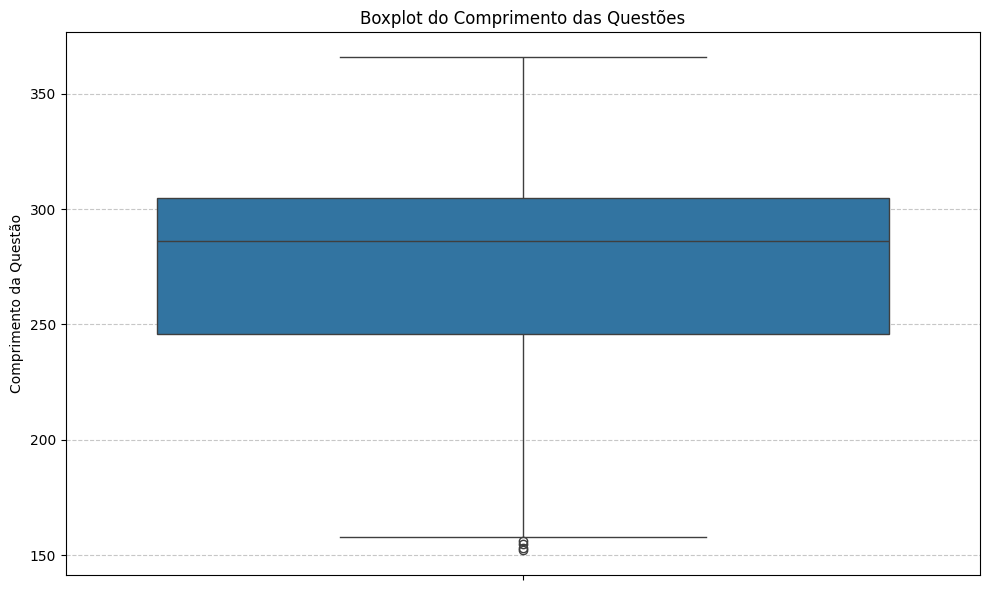

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(y='question_length', data=df_questoes)
plt.title('Boxplot do Comprimento das Questões')
plt.ylabel('Comprimento da Questão')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.6 Questões Duplicatas
👉 Deve ser proximo de zero

In [84]:
print("Duplicatas:", df_questoes['question'].duplicated().sum())

Duplicatas: 0


In [66]:
df_questoes["question"].nunique()

5000

### 1.7 Similaridade das Questões
👉 Se alto → dataset repetitivo

In [85]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df_questoes['question'])

similarity = cosine_similarity(X)

# pares muito parecidos
threshold = 0.9
duplicates = (similarity > threshold).sum()

print("Alta similaridade:", duplicates)

Alta similaridade: 5474


### 1.8 Avaliação por Split para o Treinamento (fundamental)
👉 Todos os splits devem ter distribuição parecida

In [86]:
for split in ['train', 'validation', 'test']:
    print("\n", split)
    print(df_questoes[df_questoes['split']==split]['domain'].value_counts(normalize=True))


 train
domain
People      0.344009
Business    0.328281
Process     0.327709
Name: proportion, dtype: float64

 validation
domain
Process     0.353925
Business    0.337194
People      0.308880
Name: proportion, dtype: float64

 test
domain
People      0.344353
Business    0.341598
Process     0.314050
Name: proportion, dtype: float64


### 1.9 Score de Qualidade (heurístico)

Interpretação Final

0–1	Fraco
2	Médio
3	Bom

In [87]:
score = 0

# balanceamento respostas
if df_questoes['correct_answer'].value_counts(normalize=True).std() < 0.05:
    score += 1

# balanceamento domínio
if df_questoes['domain'].value_counts(normalize=True).std() < 0.1:
    score += 1

# duplicatas
if df_questoes['question'].duplicated().sum() < 10:
    score += 1

print("Dataset Quality Score:", score, "/ 3")

Dataset Quality Score: 3 / 3


### 1.10 Análise da Distribuição por Dificuldade

### 1.11 Análise Cruzada de Dificuldade e Domínio

In [88]:
# Criar tabela de contingência entre 'difficulty' e 'domain'
crosstab_df = pd.crosstab(df_questoes['difficulty'], df_questoes['domain'])

print("Tabela de Contingência (Dificuldade vs. Domínio):\n")
display(crosstab_df)

# Opcionalmente, pode-se normalizar para ver proporções
print("\nTabela de Contingência Normalizada (proporções por dificuldade):\n")
display(pd.crosstab(df_questoes['difficulty'], df_questoes['domain'], normalize='index'))

Tabela de Contingência (Dificuldade vs. Domínio):



domain,Business,People,Process
difficulty,,,
easy,401,425,428
hard,390,440,420
medium,867,828,801



Tabela de Contingência Normalizada (proporções por dificuldade):



domain,Business,People,Process
difficulty,,,
easy,0.319777,0.338915,0.341308
hard,0.312000,0.352000,0.336000
medium,0.347356,0.331731,0.320913


Distribuição da Dificuldade das Questões:
 difficulty
medium    2496
easy      1254
hard      1250
Name: count, dtype: int64


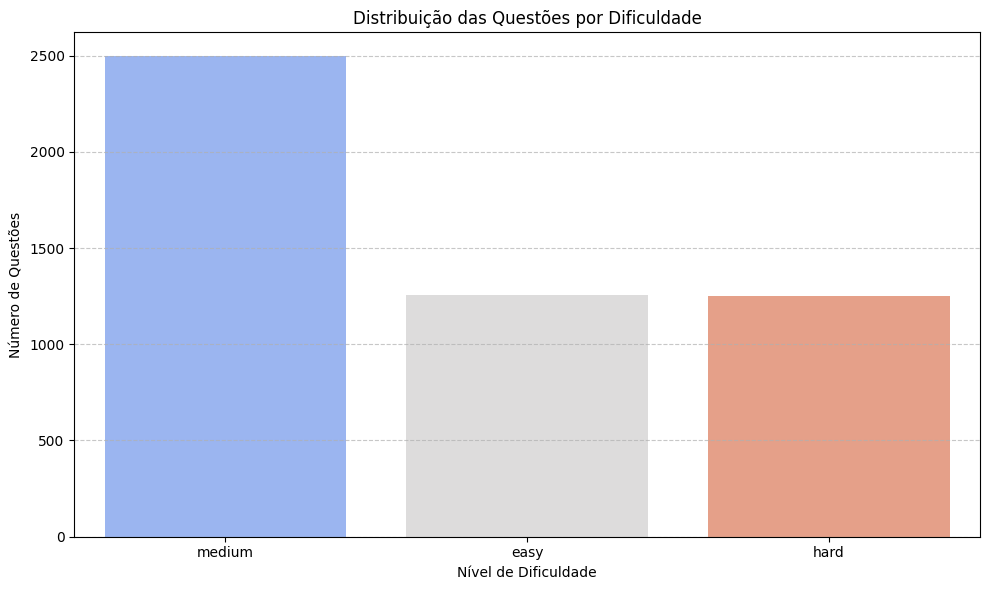

In [89]:
# Contagem de valores para a coluna 'difficulty'
distribuicao_dificuldade = df_questoes['difficulty'].value_counts()

print("Distribuição da Dificuldade das Questões:\n", distribuicao_dificuldade)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x=distribuicao_dificuldade.index, y=distribuicao_dificuldade.values, hue=distribuicao_dificuldade.index, palette='coolwarm', legend=False)
plt.title('Distribuição das Questões por Dificuldade')
plt.xlabel('Nível de Dificuldade')
plt.ylabel('Número de Questões')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 1.12 Análise Semântica das Questões

Para realizar a análise semântica das questões, podemos usar modelos de *embedding* de sentenças. Esses modelos convertem o texto das perguntas em vetores numéricos de alta dimensão, onde sentenças com significados semelhantes estarão próximas no espaço vetorial.

Usaremos a biblioteca `sentence-transformers` para isso, que provê modelos pré-treinados que são eficazes para capturar o sentido de frases.

In [90]:
# Instalar a biblioteca sentence-transformers (se ainda não estiver instalada)
!pip install -U sentence-transformers

In [91]:
from sentence_transformers import SentenceTransformer

# Carregar um modelo pré-treinado para embeddings de sentenças
# 'paraphrase-MiniLM-L6-v2' é um modelo pequeno e eficiente para similaridade de sentenças
# Você pode explorar outros modelos dependendo da sua necessidade (ex: 'all-MiniLM-L6-v2', 'distiluse-base-multilingual-cased-v2' para múltiplos idiomas)
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')

print("Modelo de Sentence-Transformer carregado com sucesso.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo de Sentence-Transformer carregado com sucesso.


In [92]:
# Gerar embeddings para a coluna 'question'
# Isso pode levar algum tempo dependendo do tamanho do dataset e do modelo escolhido
print("Gerando embeddings para as questões...")
question_embeddings = model.encode(df_questoes['question'].tolist(), show_progress_bar=True)

df_questoes['question_embedding'] = question_embeddings.tolist()

print(f"Embeddings gerados. Formato dos embeddings para a primeira questão: {len(df_questoes['question_embedding'].iloc[0])} dimensões.")
# display(df_questoes.head())

Gerando embeddings para as questões...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Embeddings gerados. Formato dos embeddings para a primeira questão: 384 dimensões.


Agora que temos os embeddings, podemos usá-los para diversas análises semânticas, como:

*   **Encontrar questões semelhantes:** Calculando a similaridade de cosseno entre os vetores.
*   **Agrupamento (Clustering):** Agrupar questões semanticamente similares.
*   **Detecção de anomalias:** Identificar questões que são semanticamente muito diferentes das outras.

Vamos demonstrar como encontrar as questões mais semanticamente similares a uma questão de exemplo.

In [93]:
from sklearn.metrics.pairwise import cosine_similarity

# Escolha uma questão de exemplo para encontrar similares
example_question_index = 0
example_question = df_questoes['question'].iloc[example_question_index]
example_embedding = question_embeddings[example_question_index]

print(f"Questão de Exemplo ({example_question_index}):\n{example_question}\n")

# Calcular a similaridade de cosseno entre a questão de exemplo e todas as outras questões
similarities = cosine_similarity([example_embedding], question_embeddings)

# Obter os índices das questões mais semelhantes (excluindo a própria questão de exemplo)
similar_indices = similarities.argsort()[0][::-1][1:6] # Top 5 mais similares

print("Top 5 Questões Mais Semelhantes:\n")
for i, idx in enumerate(similar_indices):
    similarity_score = similarities[0][idx]
    question_text = df_questoes['question'].iloc[idx]
    print(f"  {i+1}. Similaridade: {similarity_score:.4f} - Questão ({idx}): {question_text}\n")

Questão de Exemplo (0):
On a public sector modernization project, a project manager is responsible for delivery under a Agile lifecycle. The steering committee questions whether the project still supports strategy. The situation affects both delivery predictability and stakeholder confidence. Which action should the project manager take next?

Top 5 Questões Mais Semelhantes:

  1. Similaridade: 0.9245 - Questão (1343): On a supply chain improvement project, a project manager is responsible for delivery under a Agile lifecycle. The project is on schedule but stakeholders say communication is poor. The situation affects both delivery predictability and stakeholder confidence. Which action should the project manager take next?

  2. Similaridade: 0.9224 - Questão (3845): On a supply chain improvement project, a project manager is responsible for delivery under a Predictive lifecycle. The steering committee questions whether the project still supports strategy. The issue has moderate impa

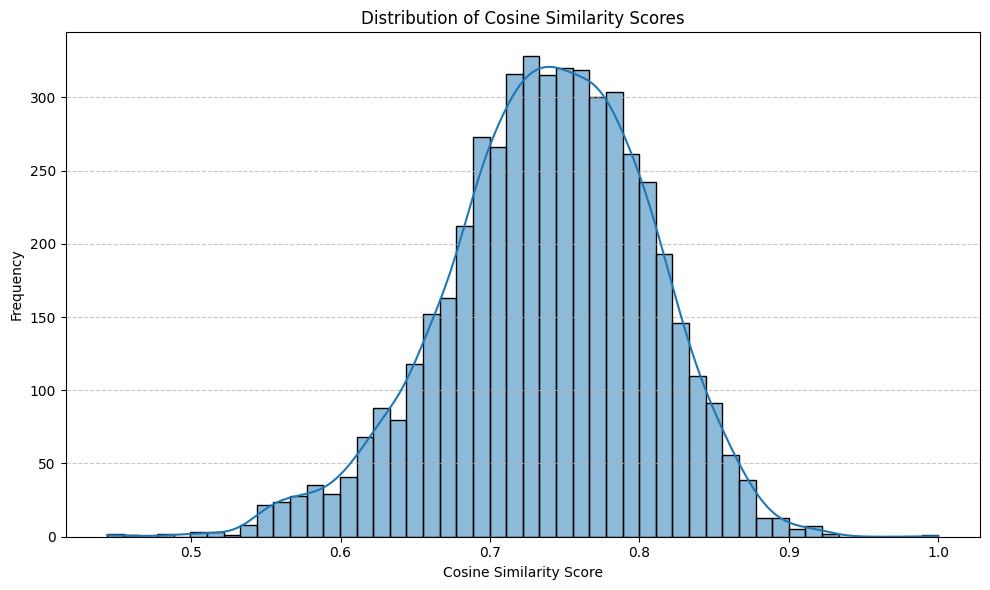

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten the similarities array for the histogram, or select the relevant row
# The previous 'similarities' array is a 1xN array, so we take the first row.
similarity_scores_flat = similarities[0]

plt.figure(figsize=(10, 6))
sns.histplot(similarity_scores_flat, bins=50, kde=True)
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 1.13 Identificação dos Pares de Questões Mais Dissimilares

Para encontrar os pares de questões mais dissimilares no dataset, calculamos a similaridade de cosseno entre *todas* as questões e, em seguida, identificamos os pares com os menores valores de similaridade (excluindo a similaridade de uma questão consigo mesma, que sempre será 1).

In [95]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Calcular a matriz de similaridade de cosseno para todos os pares de questões
# Isso pode ser computacionalmente intensivo para datasets muito grandes
all_pairs_similarities = cosine_similarity(question_embeddings)

# Para encontrar os pares mais dissimilares, precisamos encontrar os valores mínimos na matriz,
# mas devemos ignorar a diagonal (similaridade de uma questão com ela mesma, que é 1).

# Preencher a diagonal com um valor alto para que argsort não a selecione
np.fill_diagonal(all_pairs_similarities, 1.0 + 1e-6) # Valor ligeiramente maior que 1

# Obter os índices dos 5 pares mais dissimilares (menores similaridades)
# Usaremos np.unravel_index para converter os índices planos para 2D

k = 5 # Número de pares mais dissimilares a encontrar
dissimilar_indices_flat = np.argsort(all_pairs_similarities.flatten())[:k*2] # Pegar mais para filtrar duplicatas e a si mesma

# Converter os índices planos de volta para índices 2D (linha, coluna)
dissimilar_pairs_indices = np.unravel_index(dissimilar_indices_flat, all_pairs_similarities.shape)

already_processed_pairs = set()
print(f"Top {k} Pares de Questões Mais Dissimilares:\n")
count = 0
for i, j in zip(dissimilar_pairs_indices[0], dissimilar_pairs_indices[1]):
    # Evitar pares (A,B) e (B,A) e questões com elas mesmas
    if i == j or (j, i) in already_processed_pairs or (i, j) in already_processed_pairs:
        continue

    similarity_score = all_pairs_similarities[i, j]
    question_1 = df_questoes['question'].iloc[i]
    question_2 = df_questoes['question'].iloc[j]

    print(f"  {count+1}. Similaridade: {similarity_score:.4f}\n     Questão {i}: {question_1}\n     Questão {j}: {question_2}\n")
    already_processed_pairs.add((i, j))
    count += 1
    if count >= k:
        break

# Resetar a diagonal para o valor original se necessário para análises futuras
np.fill_diagonal(all_pairs_similarities, 1.0)

Top 5 Pares de Questões Mais Dissimilares:

  1. Similaridade: 0.2792
     Questão 1551: A Predictive project is underway for a customer-facing product release. A critical defect appears shortly before a planned release. The team has limited time to respond before the next status review. What is the most appropriate response?
     Questão 3348: A project manager has recently joined a mobile application delivery project, which follows a Agile approach. A stakeholder bypasses the agreed communication channels. What is the best course of action?

  2. Similaridade: 0.2826
     Questão 1551: A Predictive project is underway for a customer-facing product release. A critical defect appears shortly before a planned release. The team has limited time to respond before the next status review. What is the most appropriate response?
     Questão 3643: On a distributed software implementation, a project manager is responsible for delivery under a Agile lifecycle. A functional manager pulls a criti

### 1.14 Agrupamento (Clustering) de Questões por Tópico

Para identificar grupos de questões com tópicos semanticamente similares, podemos aplicar algoritmos de agrupamento (clustering) sobre os *embeddings* das sentenças. Usaremos o algoritmo K-Means, que é popular e eficiente para este tipo de tarefa.

Escolher o número ideal de clusters (K) pode ser um desafio e geralmente requer experimentação ou métodos como o "método do cotovelo" (elbow method). Para começar, vamos definir um número razoável de clusters e depois visualizá-los.

In [96]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Definir o número de clusters desejado
num_clusters = 5

# Aplicar K-Means nos embeddings das questões
# random_state para reprodutibilidade
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(question_embeddings)

# Adicionar os rótulos dos clusters ao DataFrame original
df_questoes['cluster_label'] = cluster_labels

print(f"Agrupamento K-Means concluído com {num_clusters} clusters.")
print("Distribuição dos clusters:")
print(df_questoes['cluster_label'].value_counts().sort_index())

Agrupamento K-Means concluído com 5 clusters.
Distribuição dos clusters:
cluster_label
0     474
1     494
2    1293
3    1330
4    1409
Name: count, dtype: int64


#### Visualização dos Clusters

Para visualizar os clusters em 2D, precisamos reduzir a dimensionalidade dos *embeddings* de 384 dimensões. Usaremos o t-SNE (t-Distributed Stochastic Neighbor Embedding) ou PCA para essa finalidade, que são técnicas eficazes para projetar dados de alta dimensão em um espaço de menor dimensão, preservando as relações de similaridade tanto quanto possível.

Reduzindo dimensionalidade com t-SNE para visualização...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


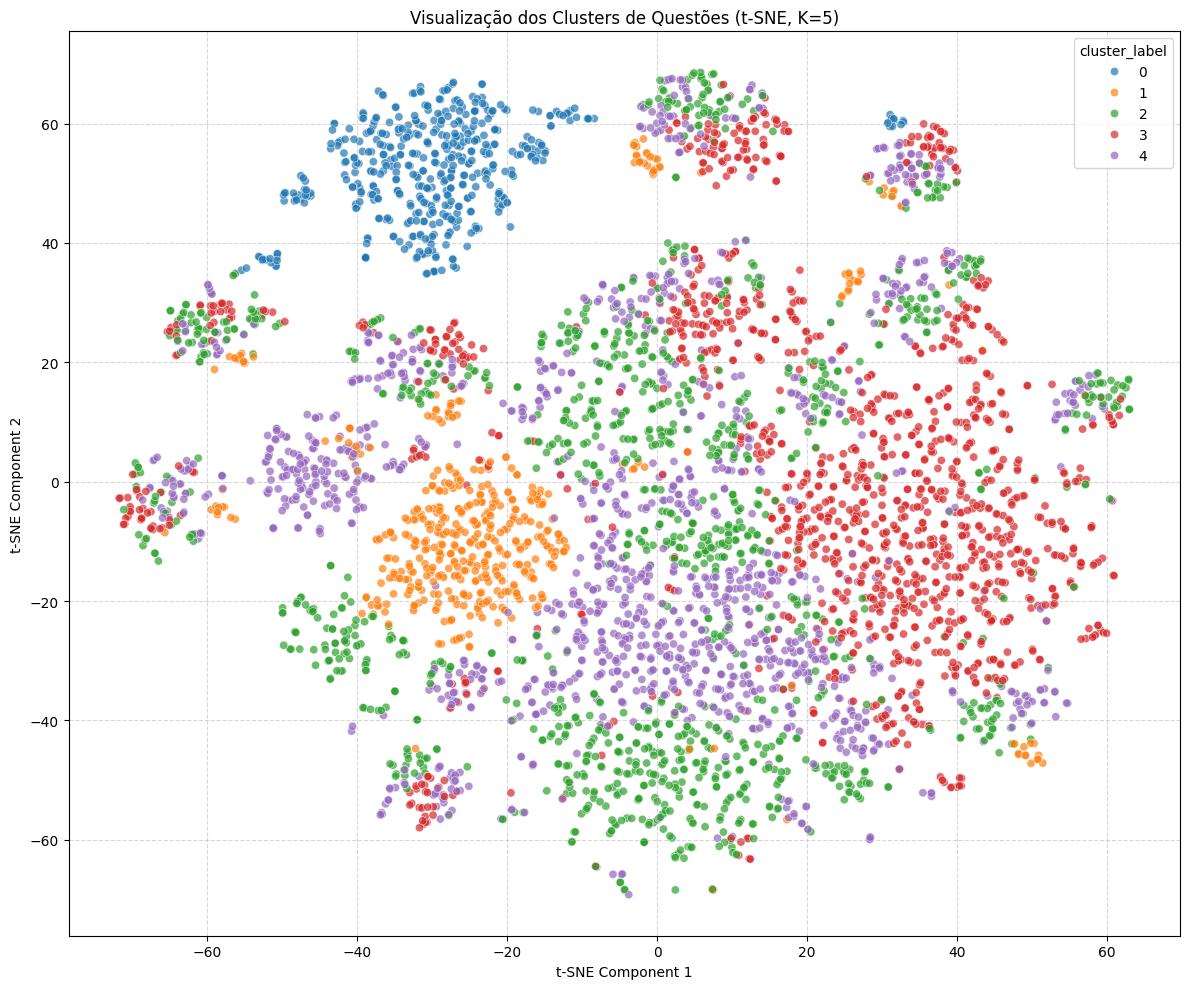

In [97]:
# Redução de dimensionalidade para visualização (t-SNE)
# Pode levar algum tempo para datasets grandes
print("Reduzindo dimensionalidade com t-SNE para visualização...")
tsne_model = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
reduced_embeddings = tsne_model.fit_transform(question_embeddings)

# Adicionar as coordenadas 2D ao DataFrame para plotagem
df_questoes['tsne_x'] = reduced_embeddings[:, 0]
df_questoes['tsne_y'] = reduced_embeddings[:, 1]

plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='tsne_x', y='tsne_y',
    hue='cluster_label',
    palette=sns.color_palette('tab10', num_clusters),
    data=df_questoes,
    legend='full',
    alpha=0.7
)
plt.title(f'Visualização dos Clusters de Questões (t-SNE, K={num_clusters})')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Análise de Exemplo de Questões por Cluster

Vamos inspecionar algumas questões de cada cluster para entender melhor os tópicos que cada grupo representa.

In [80]:
for i in range(num_clusters):
    print(f"\n--- Exemplos do Cluster {i} ---")
    cluster_questions = df_questoes[df_questoes['cluster_label'] == i]['question'].sample(min(3, len(df_questoes[df_questoes['cluster_label'] == i])), random_state=42)
    for j, question in enumerate(cluster_questions):
        print(f"  {j+1}. {question}")


--- Exemplos do Cluster 0 ---
  1. In a cloud migration project, the project team is operating with a Hybrid delivery model. The budget forecast shows a possible overrun next quarter. The project manager must balance delivery speed, stakeholder trust, and governance expectations. Which action best aligns with PMI's project management principles?
  2. A project manager is leading a process optimization initiative using a Hybrid approach. A compliance audit identifies missing documentation. The team has limited time to respond before the next status review. Which action best aligns with PMI's project management principles?
  3. The project manager is accountable for an internal operations improvement project, delivered through a Agile model. The customer asks for faster delivery without reducing scope. The issue has moderate impact, but several stakeholders have different expectations. Which action best aligns with PMI's project management principles?

--- Exemplos do Cluster 1 ---
  1.